# Holinshed name extraction — five views of `name_extraction/output/`

Five one-page visualizations built from the extractor's CSVs. Every file shares the
schema `paragraph_number, name, start_offset, end_offset, left_context, right_context,
full_context`, which gives three usable dimensions:

| Dimension | Column | What it supports |
|---|---|---|
| **Frequency** | `name` | who dominates a text |
| **Position** | `paragraph_number` | where a figure enters and leaves the narrative |
| **Role** | `left_context` + `name` | the honorific attached to a figure (`Sir`, `Lorde`, `king`, `maister`) |

The five figures:

1. **Named-entity profile sheet** — ranked mentions beside a positional strip plot, per corpus.
2. **Title / honorific heatmap** — name x honorific, showing how each figure is addressed.
3. **Co-occurrence network** — names linked when they share a paragraph.
4. **Extraction-quality audit** — non-person tokens and merge candidates per corpus.
5. **Four-corpus comparison** — small multiples of scale, diversity and positional density.

Figures are written to `name_extraction/output/figures/`.

## Setup

In [1]:
from pathlib import Path
import re
import itertools
import collections

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns
import networkx as nx

# --- Palette -------------------------------------------------------------
# Categorical slots 1-3 only: that trio is validated for all-pairs colour-vision
# separation (worst CVD dE 9.2, worst normal-vision dE 24.0 on this surface).
# Aqua sits below 3:1 contrast, so every mark drawn in it carries a visible label.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

SURFACE   = "#fcfcfb"
EMPTY     = "#f2f1ed"   # "no data" cell fill, distinct from the ramp's lightest step
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"

# Single-hue sequential ramp (light -> dark) for magnitude encodings.
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
             "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
BLUES = LinearSegmentedColormap.from_list("holinshed_blues", BLUE_RAMP)

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})


def style_axes(ax, xgrid=False, ygrid=False):
    """Recessive chrome: hairline grid only where asked, no top/right spines."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)
        ax.spines[side].set_linewidth(0.8)
    ax.grid(False)                      # clear whatever the style set
    for axis, on in (("x", xgrid), ("y", ygrid)):
        if on:                          # passing line props with visible=False turns it ON
            ax.grid(axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def page_title(fig, title, subtitle, x=0.0, y=1.0, gap=0.038):
    """Title and subtitle in figure coords, so they can never collide."""
    fig.text(x, y, title, fontsize=14, fontweight="bold", color=INK,
             ha="left", va="bottom")
    fig.text(x, y - gap, subtitle, fontsize=9.5, color=MUTED, ha="left", va="bottom")


FIG_DIR = Path("name_extraction/output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path)
    print(f"saved -> {path}")

## Load and normalize

`name_contexts.csv` is verified below to be an exact 25-row subset of
`multiple_names_contexts.csv` (Elizabeth mentions only), so it is excluded from the
corpus comparisons to avoid double-counting.

Normalization does four things:

- folds the long *s* (`ſ`) to `s`, so `ſir` / `sir` / `Sir` collapse into one honorific;
- splits a title embedded in the name (`king Edward`, `Erle of Essex`, `Queene Marie`)
  into a `title` and a `base_name`;
- strips regnal tails (`Edward the third` → `Edward`);
- marks tokens that are not person names at all — a bare title (`Queene`), a lowercase
  common noun (`miles`, `riuers`), or a country from a short explicit stoplist
  (`England`, `Ireland`). The stoplist is deliberately tiny and listed in full, since
  place-derived *titles* like `Essex` and `Warwike` must be kept.

In [2]:
OUT = Path("name_extraction/output")

CORPORA = {
    "Holinshed_vol1_book1_name_contexts.csv": "Vol. 1, Book 1",
    "Holinshed_vol3_book3_name_contexts.csv": "Vol. 3, Book 3",
    "holinshed_elizabeth_excerpt_analysis_s_name_contexts.csv": "Elizabeth excerpt",
    "multiple_names_contexts.csv": "Multi-name probe",
}
CORPUS_ORDER = list(CORPORA.values())
SHORT = {"Vol. 1, Book 1": "Vol.1 Bk.1", "Vol. 3, Book 3": "Vol.3 Bk.3",
         "Elizabeth excerpt": "Elizabeth", "Multi-name probe": "Multi-name"}

# Countries only. Place-derived titles (Essex, Warwike, Northfolke) are NOT here.
PLACE_STOPLIST = {"england", "ireland", "scotland", "fraunce", "france", "wales",
                  "britaine", "britayne", "london", "rome"}

_sub = pd.read_csv(OUT / "name_contexts.csv")
_sup = pd.read_csv(OUT / "multiple_names_contexts.csv")
_hit = _sub.merge(_sup, how="left", indicator=True)["_merge"].eq("both").sum()
print(f"name_contexts.csv: {_hit}/{len(_sub)} rows also in multiple_names_contexts.csv "
      f"-> {'exact subset, excluded' if _hit == len(_sub) else 'NOT a subset, keep it'}")


def fold_long_s(text: str) -> str:
    """Early-modern orthography -> modern, for matching only."""
    return (str(text).replace("ſ", "s")   # long s
                     .replace("ﬅ", "st")  # st ligature
                     .replace("é", "e")   # thrée -> three
                     .replace("ũ", "u"))


TITLE_RULES = [
    ("Sir",     r"^sirr?$"),
    ("Lord",    r"^lord(e|es|s)?$"),
    ("Lady",    r"^lad(ie|y|yes)$"),
    ("King",    r"^k(i|y)ngs?e?$"),
    ("Queen",   r"^qu(e|é)+ne?$"),
    ("Duke",    r"^duk(e|es)?$"),
    ("Earl",    r"^(erle|earle|earl|erles|count|countie)$"),
    ("Master",  r"^ma(i|y)?ste?r$"),
    ("Captain", r"^capta(i|y)ne?$"),
    ("Saint",   r"^sain(c)?te?$"),
    ("Prince",  r"^prince(sse)?$"),
    ("Bishop",  r"^b(i|y)ss?hopp?e?$"),
]
TITLE_ORDER = ["King", "Queen", "Prince", "Duke", "Earl", "Lord", "Lady",
               "Sir", "Master", "Captain", "Bishop", "Saint"]
REGNAL_TAIL = re.compile(r"\s+the\s+\w+$", re.IGNORECASE)


def match_title(token: str):
    tok = fold_long_s(token).strip(" ,.;:&").lower()
    if not tok:
        return None
    for canon, pattern in TITLE_RULES:
        if re.match(pattern, tok):
            return canon
    return None


def split_name(raw: str):
    """-> (title, base_name, is_bare_title). 'Erle of Essex' -> ('Earl','Essex',False)."""
    raw = str(raw)
    parts = raw.split()
    if not parts:
        return None, raw, False
    title = match_title(parts[0])
    if title is None:
        return None, REGNAL_TAIL.sub("", raw).strip(), False
    rest = parts[1:]
    if rest and fold_long_s(rest[0]).lower() == "of":
        rest = rest[1:]
    base = REGNAL_TAIL.sub("", " ".join(rest)).strip()
    if not base:                       # the whole token was a title: "Queene", "Lorde"
        return None, raw, True
    return title, base, False


def preceding_title(left_context: str):
    toks = str(left_context).split()
    return match_title(toks[-1]) if toks else None


frames = []
for filename, label in CORPORA.items():
    d = pd.read_csv(OUT / filename)
    d["corpus"] = label
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df["corpus"] = pd.Categorical(df["corpus"], categories=CORPUS_ORDER, ordered=True)
for c in ("left_context", "right_context", "full_context"):
    df[c] = df[c].fillna("")

_split = [split_name(n) for n in df["name"]]
df["name_title"] = [t for t, _, _ in _split]
df["base_name"] = [b for _, b, _ in _split]
df["is_bare_title"] = [x for _, _, x in _split]
df["context_title"] = [preceding_title(c) for c in df["left_context"]]
# A figure's honorific: one embedded in the name wins, else the preceding word.
df["title"] = df["name_title"].fillna(df["context_title"])
df["base_key"] = df["base_name"].map(lambda s: fold_long_s(s).lower())

# --- quality buckets ------------------------------------------------------
CLEAN   = "Person name"
MERGE   = "Merge candidate (title-led duplicate)"
NONNAME = "Non-person token (noun, place, bare title)"
BUCKETS = [CLEAN, MERGE, NONNAME]
BUCKET_COLOR = {CLEAN: BLUE, MERGE: ORANGE, NONNAME: AQUA}

bare_by_corpus = {
    c: set(df.loc[(df["corpus"] == c) & df["name_title"].isna(), "base_key"])
    for c in CORPUS_ORDER
}


def bucket(row):
    if row["is_bare_title"] or row["base_key"] in PLACE_STOPLIST:
        return NONNAME
    if pd.isna(row["name_title"]) and row["name"][:1].islower():
        return NONNAME
    if pd.notna(row["name_title"]) and row["base_key"] in bare_by_corpus[row["corpus"]]:
        return MERGE
    return CLEAN


df["quality"] = pd.Categorical([bucket(r) for _, r in df.iterrows()],
                               categories=BUCKETS, ordered=True)
clean = df[df["quality"] == CLEAN].copy()

print(f"\n{len(df)} mentions | {df['base_key'].nunique()} distinct surface figures | "
      f"{len(CORPORA)} corpora")
print(f"{len(clean)} ({len(clean)/len(df):.0%}) classified as person names")
df[["corpus", "paragraph_number", "name", "title", "base_name", "quality"]].head()

name_contexts.csv: 25/25 rows also in multiple_names_contexts.csv -> exact subset, excluded

1571 mentions | 154 distinct surface figures | 4 corpora
1249 (80%) classified as person names


,corpus,paragraph_number,name,title,base_name,quality
0,"Vol. 1, Book 1",12,riuers,NaN,riuers,"Non-person token (noun, place, bare title)"
1,"Vol. 1, Book 1",13,riuers,NaN,riuers,"Non-person token (noun, place, bare title)"
2,"Vol. 1, Book 1",13,miles,NaN,miles,"Non-person token (noun, place, bare title)"
3,"Vol. 1, Book 1",31,king Edward,King,Edward,Merge candidate (title-led duplicate)
4,"Vol. 1, Book 1",37,Samuell,NaN,Samuell,Person name


---
## 1. Named-entity profile sheet

The core view. For each corpus: a ranked bar of the most-mentioned figures, and beside
it the same figures plotted against `paragraph_number` — one dot per mention. The bar
answers *who matters*; the strip answers *where they are*, which is what separates a
figure running through a whole book from one confined to a single dense episode.

Deliberately drawn on **unfiltered** mentions, with anything the audit in figure 4 flags
shown in orange. A cleaned version of this chart would hide the fact that the top
"name" in Vol. 1 Book 1 is not a name at all.

saved -> name_extraction/output/figures/01_profile_vol1_bk1.png


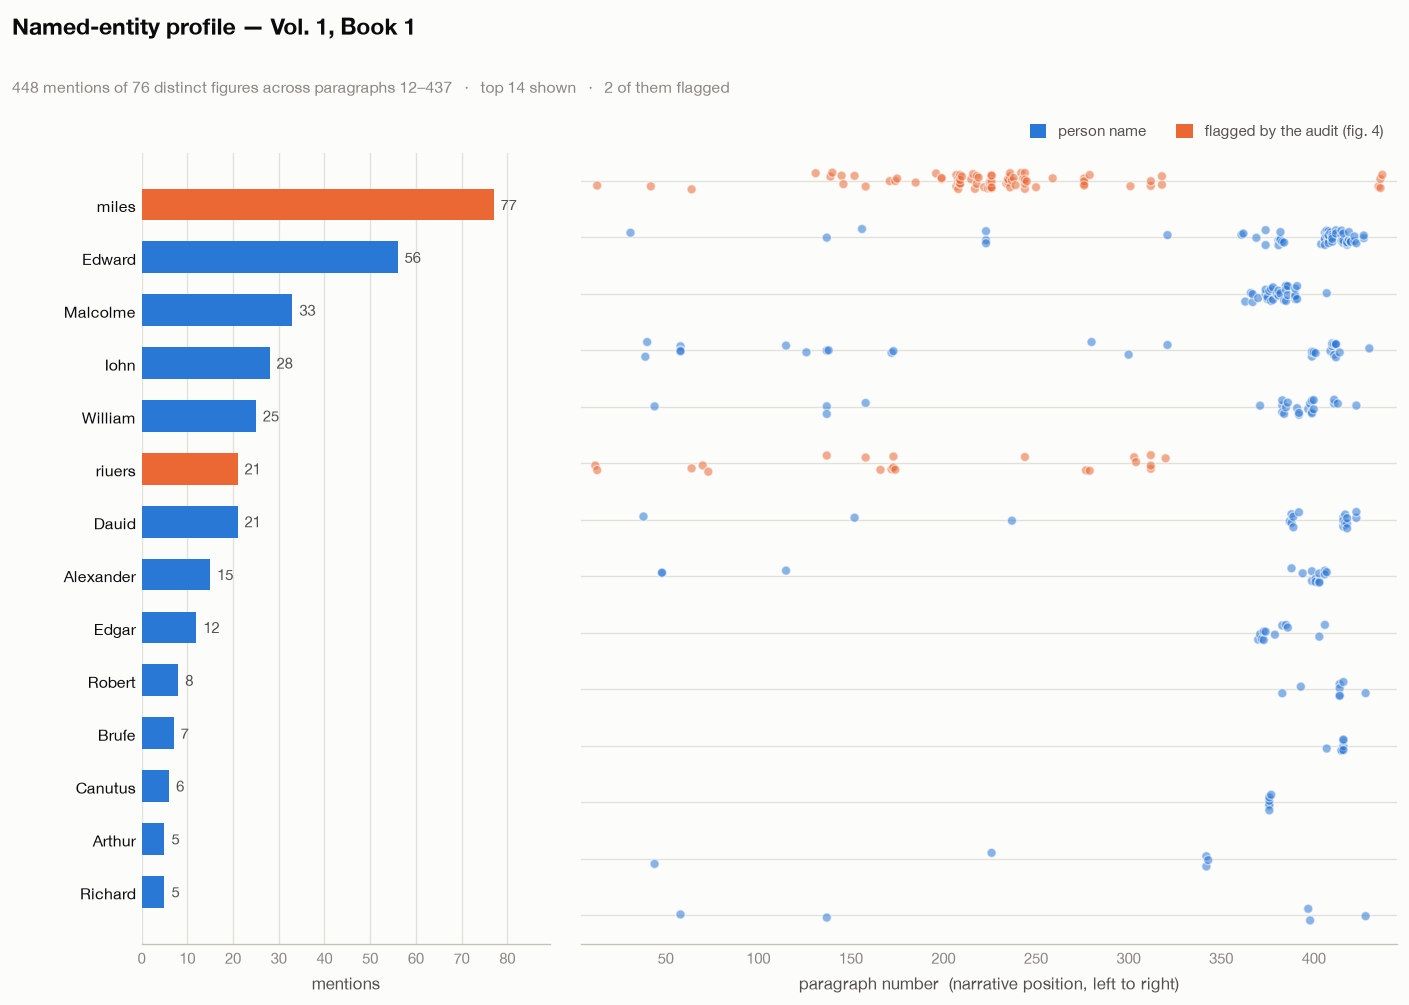

saved -> name_extraction/output/figures/01_profile_vol3_bk3.png


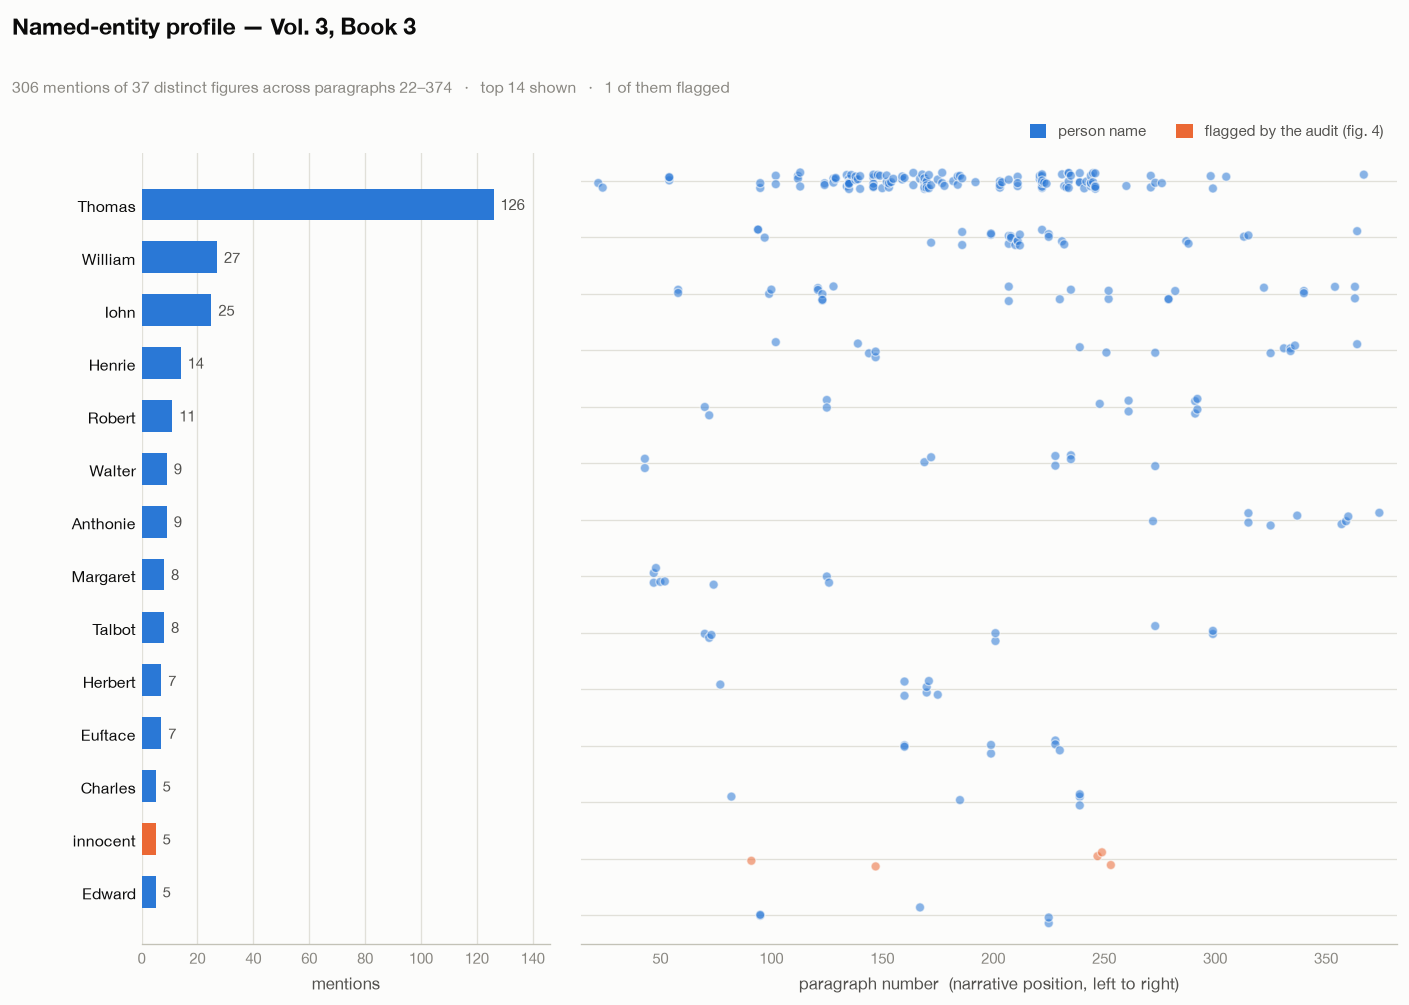

saved -> name_extraction/output/figures/01_profile_elizabeth.png


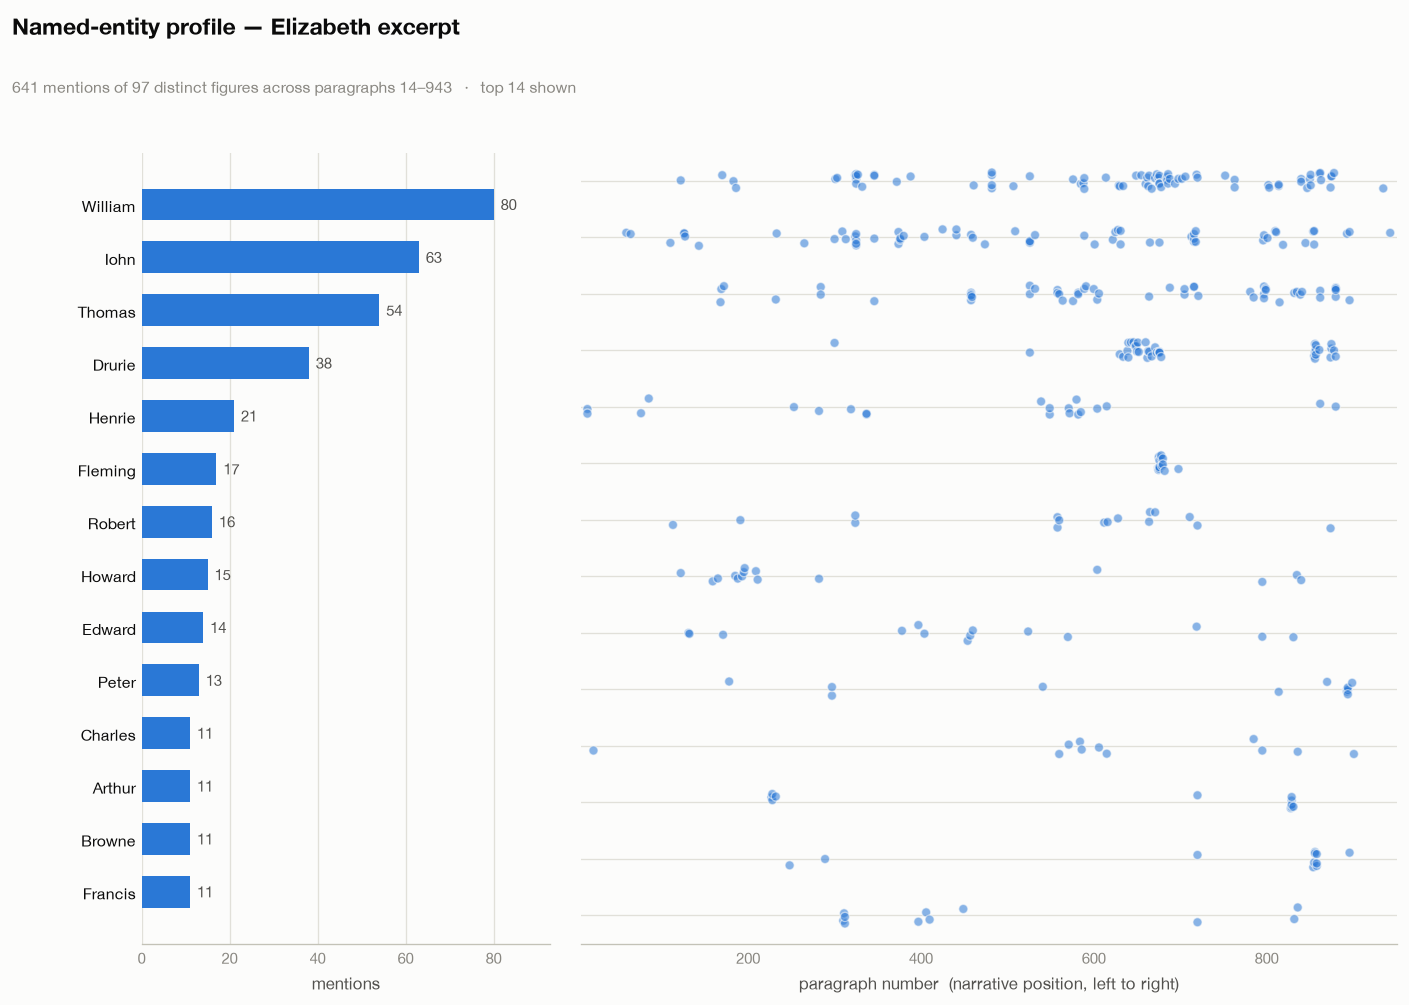

saved -> name_extraction/output/figures/01_profile_multi-name.png


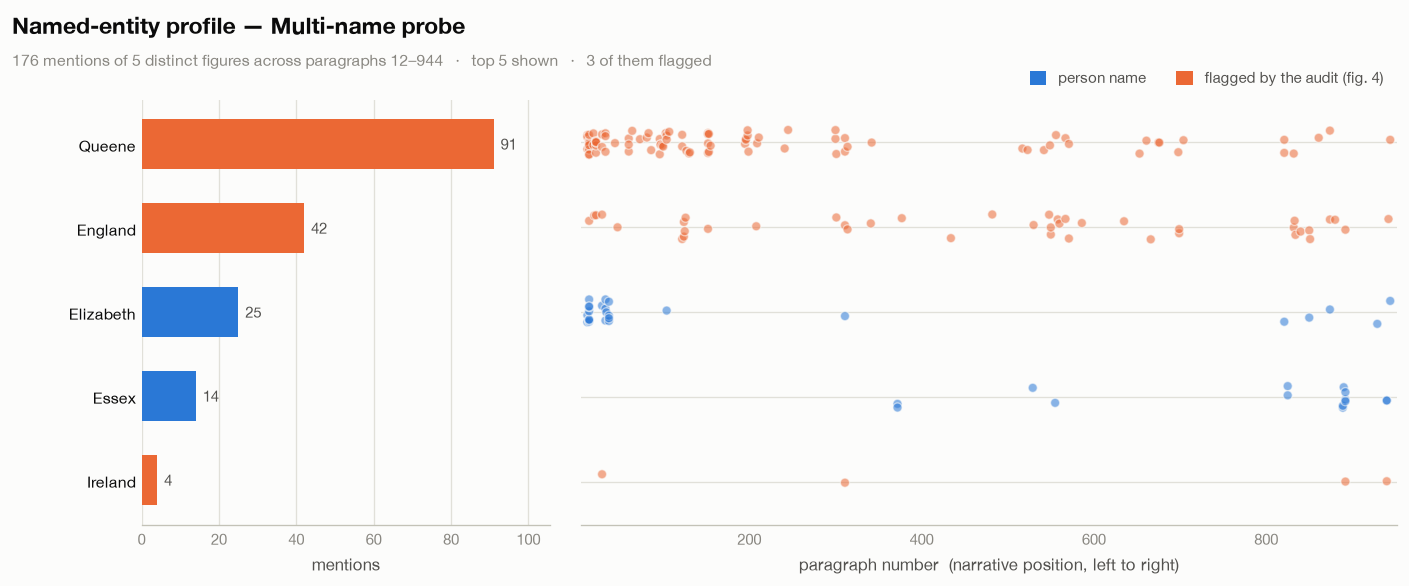

In [3]:
TOP_N = 14


def profile_sheet(corpus: str, top_n: int = TOP_N):
    sub = df[df["corpus"] == corpus]
    counts = sub["base_name"].value_counts().head(top_n)
    order = list(counts.index)                       # most-mentioned at top
    flagged = {n: (sub.loc[sub["base_name"] == n, "quality"] != CLEAN).mean() > 0.5
               for n in order}
    plot = sub[sub["base_name"].isin(order)]

    fig = plt.figure(figsize=(13.5, 0.44 * len(order) + 2.4))
    gs = GridSpec(1, 2, width_ratios=[1, 2.0], wspace=0.05, figure=fig)
    ax_bar, ax_strip = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    y = np.arange(len(order))
    colors = [ORANGE if flagged[n] else BLUE for n in order]
    ax_bar.barh(y, [counts[n] for n in order], height=0.6, color=colors, zorder=3)
    ax_bar.set_yticks(y, order, fontsize=9.5, color=INK)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("mentions")
    ax_bar.set_xlim(0, counts.max() * 1.16)
    style_axes(ax_bar, xgrid=True)
    ax_bar.spines["left"].set_visible(False)
    for yi, n in enumerate(order):                   # direct labels on every bar
        ax_bar.text(counts[n] + counts.max() * 0.02, yi, f"{counts[n]}",
                    va="center", ha="left", fontsize=9, color=INK_2)

    pos = {n: i for i, n in enumerate(order)}
    jitter = np.random.default_rng(7).uniform(-0.15, 0.15, len(plot))
    ax_strip.scatter(plot["paragraph_number"], plot["base_name"].map(pos) + jitter,
                     s=30, c=[ORANGE if flagged[n] else BLUE for n in plot["base_name"]],
                     alpha=0.55, edgecolor=SURFACE, linewidth=0.8, zorder=3)
    ax_strip.set_ylim(len(order) - 0.5, -0.5)
    ax_strip.set_yticks(y, [""] * len(order))
    ax_strip.set_xlabel("paragraph number  (narrative position, left to right)")
    style_axes(ax_strip, ygrid=True)
    ax_strip.spines["left"].set_visible(False)
    ax_strip.set_xlim(sub["paragraph_number"].min() - 8,
                      sub["paragraph_number"].max() + 8)

    n_flagged = sum(flagged.values())
    if n_flagged:
        ax_strip.legend(
            handles=[Patch(facecolor=BLUE, label="person name"),
                     Patch(facecolor=ORANGE, label="flagged by the audit (fig. 4)")],
            loc="lower right", bbox_to_anchor=(1.0, 1.0), ncols=2, frameon=False,
            fontsize=9, labelcolor=INK_2, handlelength=1.1, handleheight=1.1)

    page_title(
        fig,
        f"Named-entity profile — {corpus}",
        f"{len(sub)} mentions of {sub['base_key'].nunique()} distinct figures across "
        f"paragraphs {sub['paragraph_number'].min()}–{sub['paragraph_number'].max()}"
        f"   ·   top {len(order)} shown"
        + (f"   ·   {n_flagged} of them flagged" if n_flagged else ""),
        x=0.045, y=0.99, gap=0.055,
    )
    return fig


for corpus in CORPUS_ORDER:
    fig = profile_sheet(corpus)
    save(fig, "01_profile_" + SHORT[corpus].lower().replace(" ", "_").replace(".", ""))
    plt.show()

---
## 2. Title / honorific heatmap

Turns the context columns into a claim about rank rather than raw counts. Each cell is
the number of times a figure is addressed with a given honorific, taken from the word
preceding the name or a title embedded in it. Single-hue sequential ramp — this is
magnitude, so light-to-dark, never a rainbow. Cells with no mentions are left blank
rather than painted as the ramp's zero, and every non-empty cell is annotated, so the
colour never has to carry the value alone.

Person names only; the bare-title tokens the audit flags are excluded, since `Queene`
counted as a figure addressed as "Queen" is circular.

saved -> name_extraction/output/figures/02_honorific_heatmap.png


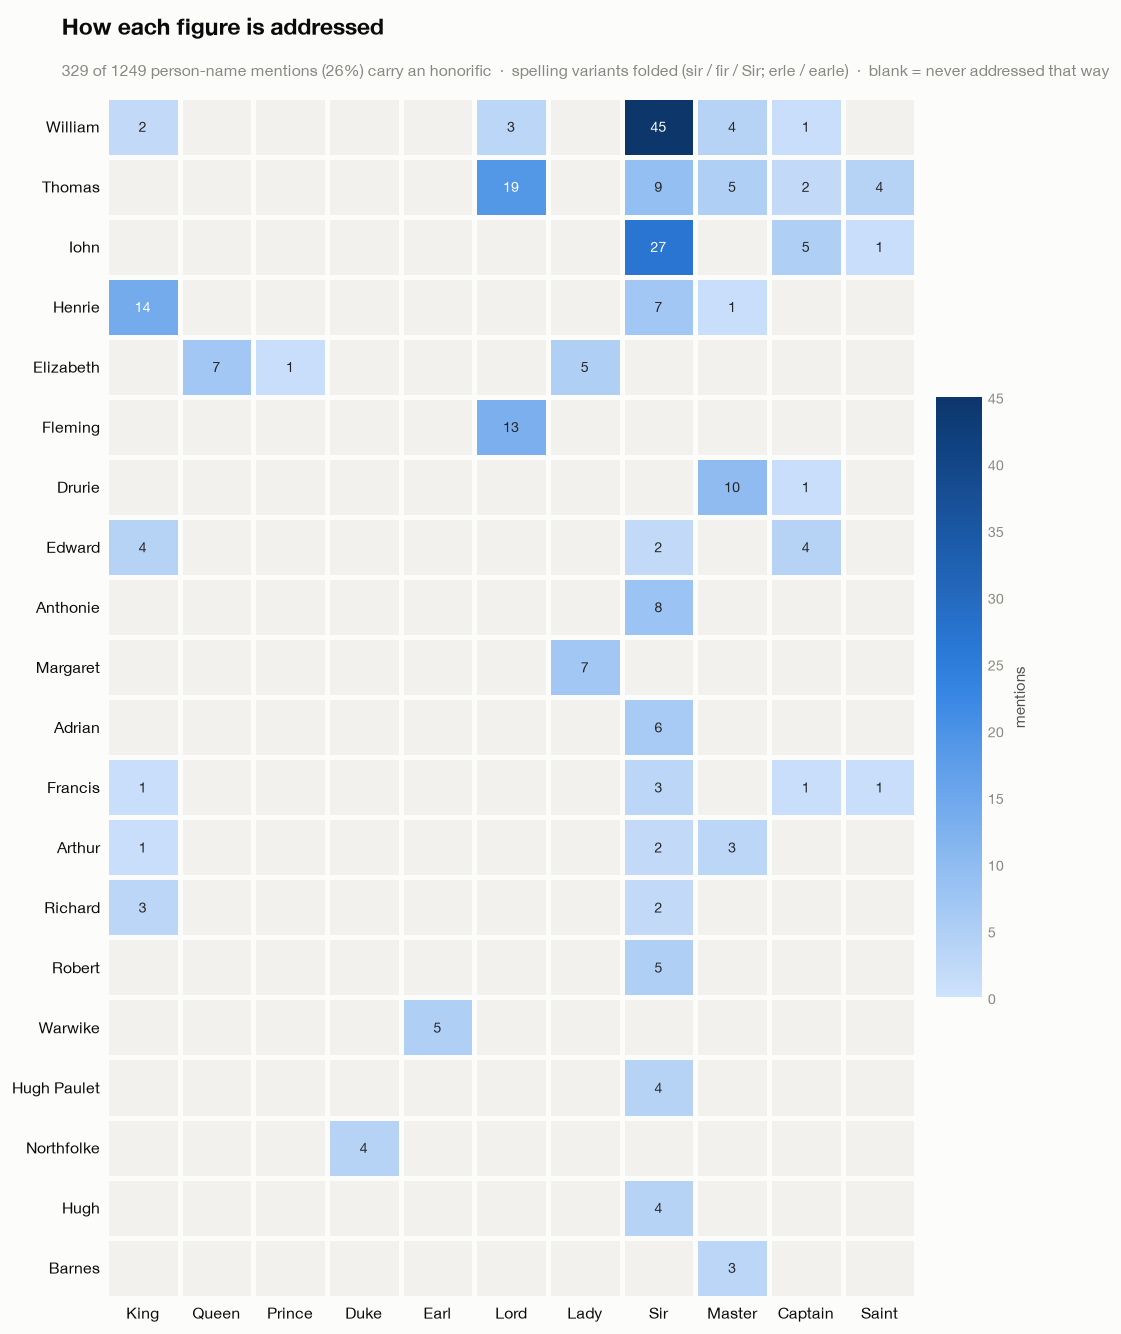


Honorific totals (person names only):
title
Sir        135
Lord        50
Master      40
King        33
Captain     18
Lady        13
Earl        12
Duke         9
Saint        9
Queen        8
Prince       2


In [4]:
titled = clean[clean["title"].notna()]

top_figures = titled["base_name"].value_counts().head(20).index
mat = (titled[titled["base_name"].isin(top_figures)]
       .pivot_table(index="base_name", columns="title", values="name",
                    aggfunc="count", fill_value=0))
mat = mat.reindex(columns=[t for t in TITLE_ORDER if t in mat.columns])
mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10.5, 0.44 * len(mat) + 2.2))
ax.set_facecolor(EMPTY)
sns.heatmap(
    mat, ax=ax, cmap=BLUES, vmin=0, mask=mat.eq(0),
    annot=True, fmt="d", annot_kws={"fontsize": 8.5},
    linewidths=2, linecolor=SURFACE,            # 2px surface gap between cells
    cbar_kws={"label": "mentions", "shrink": 0.5, "aspect": 13, "pad": 0.02},
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(length=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9.5, color=INK)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9.5, color=INK)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8.5, colors=MUTED)
cbar.set_label("mentions", color=INK_2, fontsize=9)
fig.subplots_adjust(top=0.955, bottom=0.045)

page_title(
    fig, "How each figure is addressed",
    f"{len(titled)} of {len(clean)} person-name mentions ({len(titled)/len(clean):.0%}) "
    "carry an honorific  ·  spelling variants folded (sir / ſir / Sir; erle / earle)  ·  "
    "blank = never addressed that way",
    x=0.09, y=0.998, gap=0.030,
)

save(fig, "02_honorific_heatmap")
plt.show()

print("\nHonorific totals (person names only):")
print(titled["title"].value_counts().to_string())

---
## 3. Co-occurrence network

Two figures are linked when they are named in the same paragraph; edge weight is the
number of shared paragraphs. Built on the **Elizabeth excerpt**, the densest file.
Node size encodes mention count and node colour encodes degree on the same sequential
blue ramp — one magnitude, two channels, so the low-contrast steps never carry meaning
alone.

Two filters keep this a reading rather than a hairball: edges need `MIN_WEIGHT` shared
paragraphs, and only the largest connected component is drawn. Both are reported in the
subtitle so nothing is silently dropped.

saved -> name_extraction/output/figures/03_cooccurrence_network.png


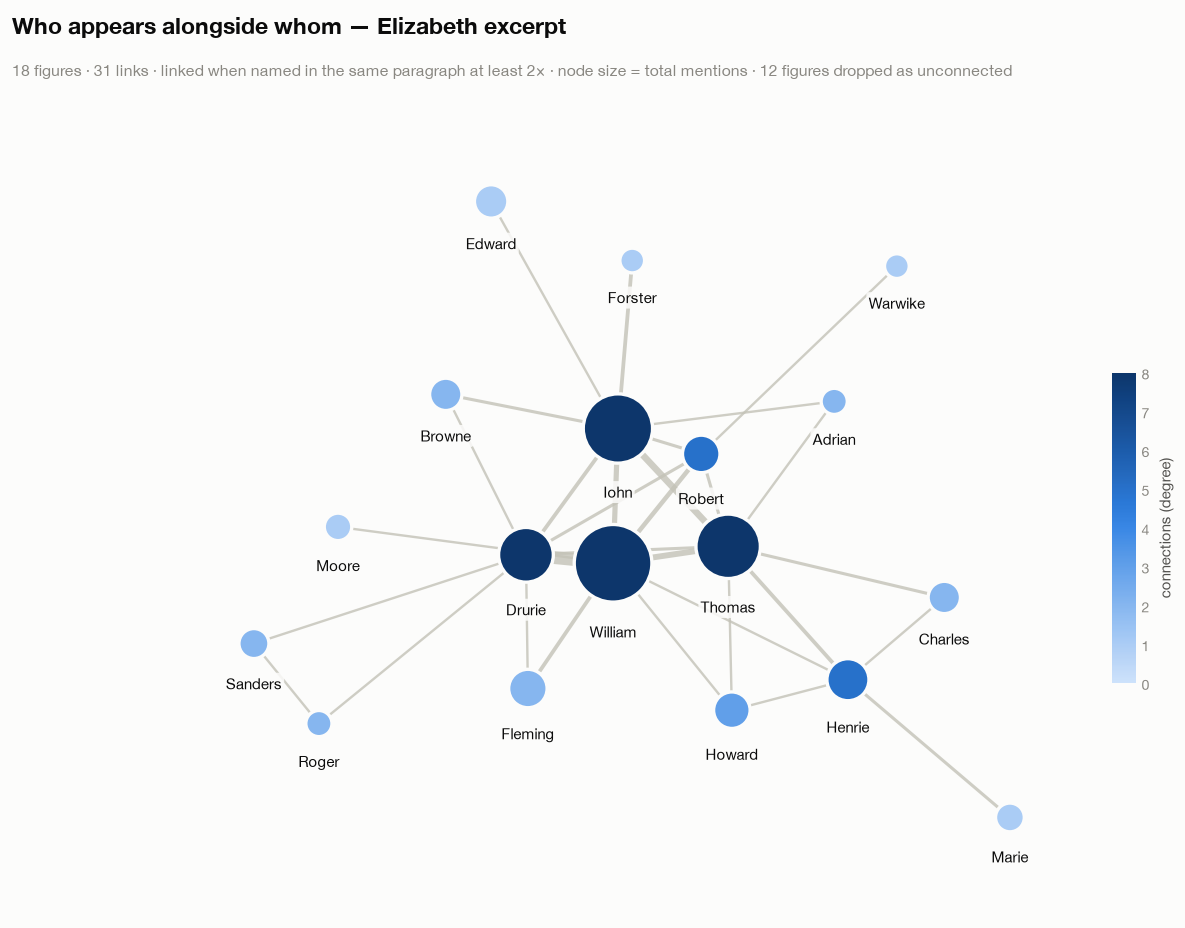


Strongest co-occurring pairs:
   17  Drurie — William
    8  Iohn — Thomas
    7  Thomas — William
    6  Iohn — William
    5  Robert — William
    4  Henrie — Thomas
    4  Forster — Iohn
    4  Fleming — William
    4  Drurie — Iohn
    3  Robert — Thomas


In [5]:
NET_CORPUS = "Elizabeth excerpt"
TOP_NODES = 30
MIN_WEIGHT = 2

sub = clean[clean["corpus"] == NET_CORPUS]
mention_counts = sub["base_name"].value_counts()
keep = mention_counts.head(TOP_NODES).index
sub = sub[sub["base_name"].isin(keep)]

pair_counts = collections.Counter()
for _, grp in sub.groupby("paragraph_number"):
    for a, b in itertools.combinations(sorted(set(grp["base_name"])), 2):
        pair_counts[(a, b)] += 1

G = nx.Graph()
G.add_nodes_from(keep)
for (a, b), w in pair_counts.items():
    if w >= MIN_WEIGHT:
        G.add_edge(a, b, weight=w)

components = sorted(nx.connected_components(G), key=len, reverse=True)
main = G.subgraph(components[0]).copy()
dropped = G.number_of_nodes() - main.number_of_nodes()
degrees = dict(main.degree())

fig, ax = plt.subplots(figsize=(12, 8.4))
pos = nx.spring_layout(main, weight="weight", k=1.5, seed=42, iterations=400)
xy = np.array(list(pos.values()))
lo, hi = xy.min(axis=0), xy.max(axis=0)
pos = {n: (p - lo) / np.where(hi - lo == 0, 1, hi - lo) for n, p in pos.items()}

weights = [main[u][v]["weight"] for u, v in main.edges()]
nx.draw_networkx_edges(main, pos, ax=ax, edge_color=BASELINE, alpha=0.8,
                       width=[0.6 + 0.42 * w for w in weights])

sizes = [90 + 26 * mention_counts[n] for n in main.nodes()]
dvals = [degrees[n] for n in main.nodes()]
nodes = nx.draw_networkx_nodes(
    main, pos, ax=ax, node_size=sizes, node_color=dvals, cmap=BLUES,
    vmin=0, vmax=max(dvals), edgecolors=SURFACE, linewidths=2.0,
)
size_of = dict(zip(main.nodes(), sizes))
for n, (x, y) in pos.items():                 # label clears the node's own radius
    offset = 0.022 + np.sqrt(size_of[n]) / 620
    ax.text(x, y - offset, n, ha="center", va="top", fontsize=9, color=INK,
            zorder=5,
            bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.85))

cbar = fig.colorbar(nodes, ax=ax, shrink=0.4, aspect=13, pad=0.01)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8.5, colors=MUTED)
cbar.set_label("connections (degree)", color=INK_2, fontsize=9)

ax.set_axis_off()
ax.set_xlim(-0.12, 1.12)
ax.set_ylim(-0.16, 1.10)

page_title(
    fig, f"Who appears alongside whom — {NET_CORPUS}",
    f"{main.number_of_nodes()} figures · {main.number_of_edges()} links · linked when "
    f"named in the same paragraph at least {MIN_WEIGHT}× · node size = total mentions"
    + (f" · {dropped} figures dropped as unconnected" if dropped else ""),
    x=0.02, y=0.98, gap=0.040,
)

save(fig, "03_cooccurrence_network")
plt.show()

print("\nStrongest co-occurring pairs:")
for w, a, b in sorted(((w, a, b) for (a, b), w in pair_counts.items()), reverse=True)[:10]:
    print(f"  {w:>3}  {a} — {b}")

---
## 4. Extraction-quality audit

A tooling finding rather than a humanities one, and it changes how the other four
figures should be read. Every mention lands in one of three buckets:

- **Person name** — what the extractor is for.
- **Merge candidate** — a title-led form whose bare name also appears in the same corpus
  (`king Edward` vs `Edward`), so one figure is counted as two.
- **Non-person token** — a lowercase common noun (`miles`, `riuers`), a bare honorific
  (`Queene`), or a country from the stoplist.

The left panel is proportional, because the corpora differ in size by 3.5×, with the raw
total printed at the end of each bar. Segments narrower than 6% are left unlabeled and
read from the table below instead — the aqua slot is below 3:1 contrast, so a value it
cannot label legibly must be recoverable another way.

The multi-name probe is the exception to read carefully: it *targets* `Queene`,
`England` and `Ireland` as search terms, so its flag rate is by construction, not an
extractor defect.

saved -> name_extraction/output/figures/04_extraction_audit.png


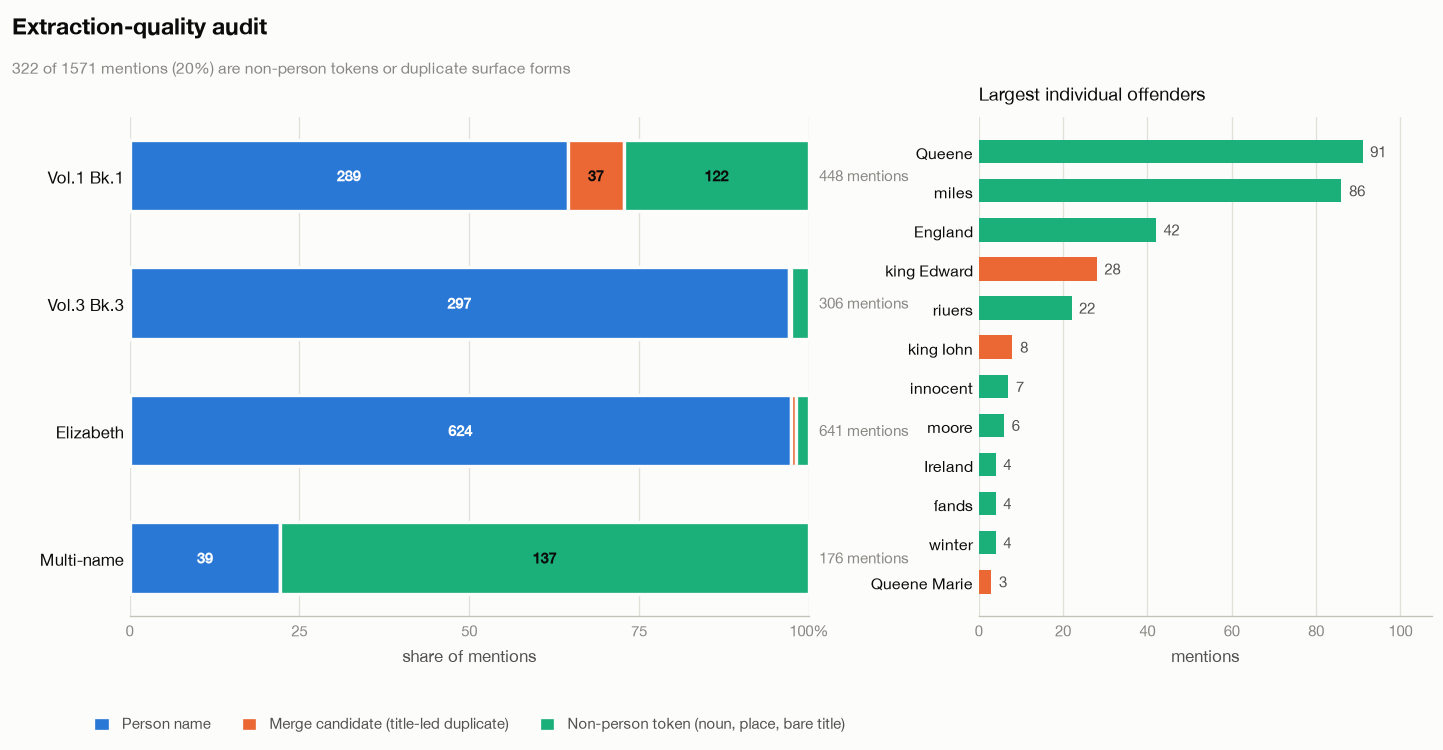


Per-corpus quality table (counts):
quality            Person name  Merge candidate (title-led duplicate)  Non-person token (noun, place, bare title)
corpus                                                                                                           
Vol. 1, Book 1             289                                     37                                         122
Vol. 3, Book 3             297                                      1                                           8
Elizabeth excerpt          624                                      5                                          12
Multi-name probe            39                                      0                                         137


In [6]:
tab = (df.pivot_table(index="corpus", columns="quality", values="name",
                      aggfunc="count", fill_value=0, observed=False)
         .reindex(columns=BUCKETS, fill_value=0)
         .reindex(CORPUS_ORDER))
totals = tab.sum(axis=1)
share = tab.div(totals, axis=0) * 100

fig, (ax, ax2) = plt.subplots(
    1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.30}
)

y = np.arange(len(tab))
left = np.zeros(len(tab))
for b in BUCKETS:
    vals = share[b].to_numpy()
    ax.barh(y, vals, left=left, height=0.56, color=BUCKET_COLOR[b], label=b,
            zorder=3, edgecolor=SURFACE, linewidth=2)     # 2px surface gap
    for yi, (v, l, raw) in enumerate(zip(vals, left, tab[b].to_numpy())):
        if v >= 6:                                        # skip labels that won't fit
            ax.text(l + v / 2, yi, f"{raw}", ha="center", va="center", fontsize=9,
                    color="#ffffff" if b == CLEAN else INK, fontweight="bold")
    left += vals

for yi, t in enumerate(totals):
    ax.text(101.5, yi, f"{t} mentions", va="center", fontsize=9, color=MUTED)

ax.set_yticks(y, [SHORT[c] for c in tab.index], fontsize=10, color=INK)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ["0", "25", "50", "75", "100%"])
ax.set_xlabel("share of mentions")
style_axes(ax, xgrid=True)
ax.spines["left"].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncols=3, frameon=False,
          fontsize=9, labelcolor=INK_2, handlelength=1.1, handleheight=1.1)

flagged = (df[df["quality"] != CLEAN]
           .groupby("name", observed=True).size().sort_values(ascending=False).head(12))
fq = df[df["quality"] != CLEAN].groupby("name", observed=True)["quality"].first()
fcolor = [BUCKET_COLOR[fq[n]] for n in flagged.index]
y2 = np.arange(len(flagged))
ax2.barh(y2, flagged.to_numpy(), height=0.6, color=fcolor, zorder=3)
ax2.set_yticks(y2, flagged.index, fontsize=9.5, color=INK)
ax2.invert_yaxis()
ax2.set_xlim(0, flagged.max() * 1.18)
ax2.set_xlabel("mentions")
style_axes(ax2, xgrid=True)
ax2.spines["left"].set_visible(False)
for yi, v in enumerate(flagged.to_numpy()):
    ax2.text(v + flagged.max() * 0.02, yi, f"{v}", va="center", fontsize=9, color=INK_2)
ax2.set_title("Largest individual offenders", fontsize=11, color=INK, loc="left", pad=10)

n_flag = int((df["quality"] != CLEAN).sum())
page_title(
    fig, "Extraction-quality audit",
    f"{n_flag} of {len(df)} mentions ({n_flag/len(df):.0%}) are non-person tokens or "
    "duplicate surface forms",
    x=0.055, y=1.0, gap=0.058,
)

save(fig, "04_extraction_audit")
plt.show()

print("\nPer-corpus quality table (counts):")
print(tab.to_string())

---
## 5. Four-corpus comparison

The contrast view. Top row: three scale measures on a shared corpus axis. Bottom row:
where mentions fall across each text, with position normalized to 0–100% of that text's
own paragraph range so texts of different lengths are comparable. One hue throughout —
identity is carried by the panel titles and axis labels, so a second colour would have
nothing to do.

Person-name mentions only, using the buckets from figure 4. The "read as" notes are
computed from the data rather than asserted, so they stay true if the extractor changes.

saved -> name_extraction/output/figures/05_corpus_comparison.png


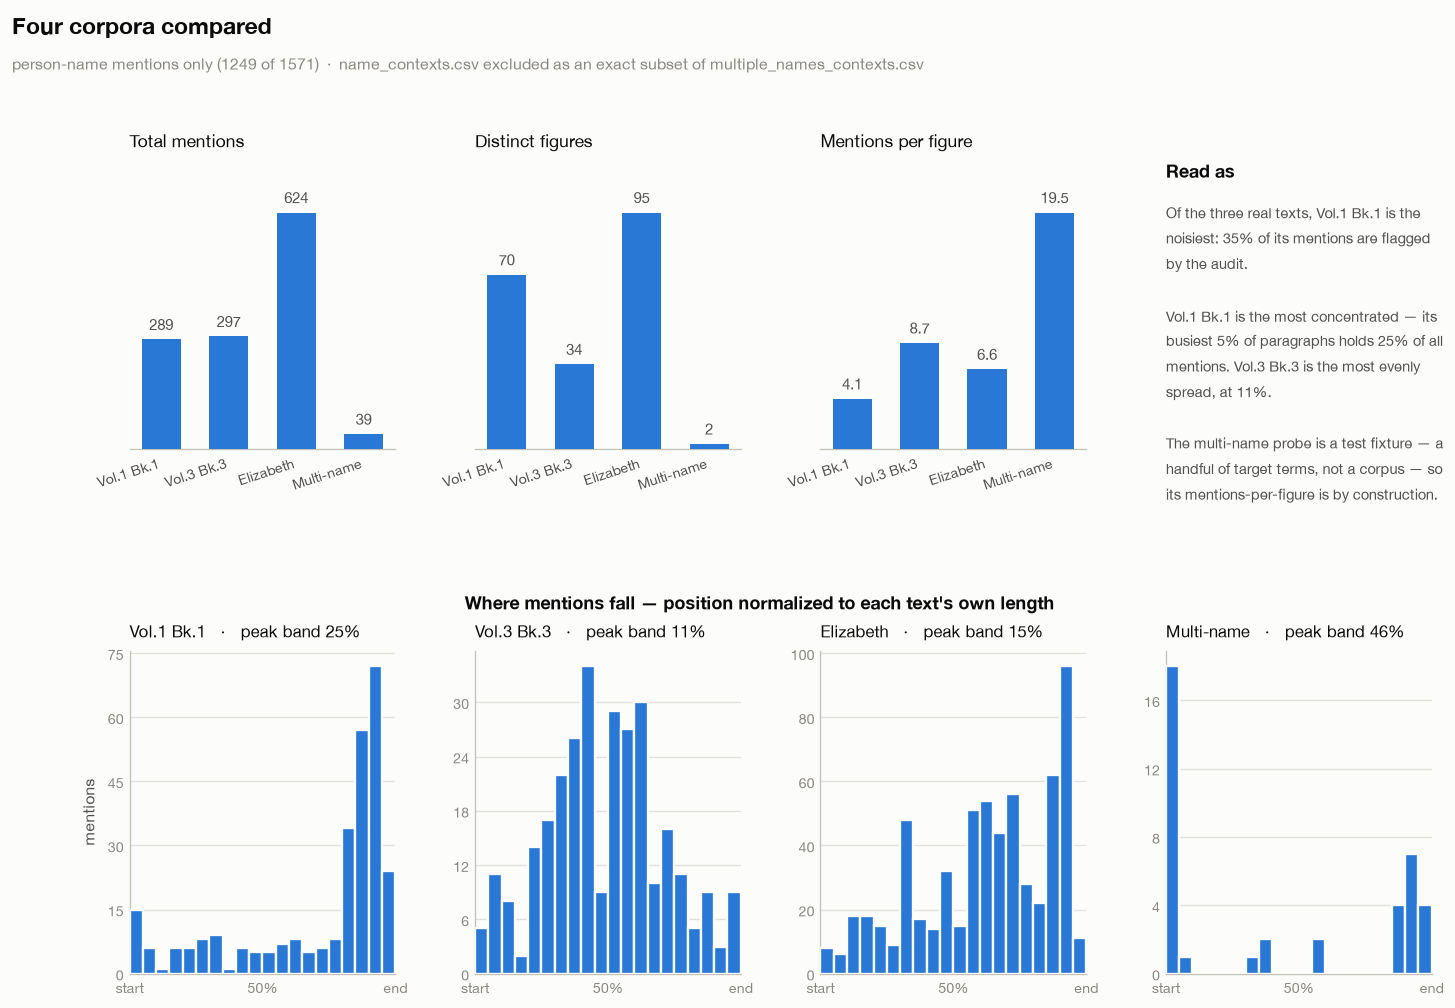

                   Total mentions  Distinct figures  Mentions per figure
corpus                                                                  
Vol. 1, Book 1                289                70                 4.13
Vol. 3, Book 3                297                34                 8.74
Elizabeth excerpt             624                95                 6.57
Multi-name probe               39                 2                19.50

peak 5%-band share: {'Vol.1 Bk.1': '25%', 'Vol.3 Bk.3': '11%', 'Elizabeth': '15%', 'Multi-name': '46%'}
audit flag rate:    {'Vol.1 Bk.1': '35%', 'Vol.3 Bk.3': '3%', 'Elizabeth': '3%', 'Multi-name': '78%'}


In [7]:
summary = pd.DataFrame({
    "Total mentions": clean.groupby("corpus", observed=False).size(),
    "Distinct figures": clean.groupby("corpus", observed=False)["base_key"].nunique(),
}).reindex(CORPUS_ORDER)
summary["Mentions per figure"] = (
    summary["Total mentions"] / summary["Distinct figures"]
).round(2)

BINS = np.linspace(0, 100, 21)


def normalized_position(corpus):
    s = clean.loc[clean["corpus"] == corpus, "paragraph_number"]
    lo, hi = s.min(), s.max()
    return (s - lo) / max(hi - lo, 1) * 100


# Concentration: share of mentions in the single busiest 5% band of the text.
peak_share = {c: np.histogram(normalized_position(c), bins=BINS)[0].max()
                 / len(normalized_position(c)) for c in CORPUS_ORDER}
flag_rate = (df["quality"] != CLEAN).groupby(df["corpus"], observed=False).mean()
# The multi-name probe is a fixture, not a text: excluded from these superlatives.
REAL = [c for c in CORPUS_ORDER if c != "Multi-name probe"]
most_even = min(REAL, key=lambda c: peak_share[c])
most_peaked = max(REAL, key=lambda c: peak_share[c])
noisiest = max(REAL, key=lambda c: flag_rate[c])

fig = plt.figure(figsize=(14, 8.8))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 1.12], hspace=0.66, wspace=0.30)

xs = np.arange(len(CORPUS_ORDER))
labels = [SHORT[c] for c in CORPUS_ORDER]

for i, metric in enumerate(["Total mentions", "Distinct figures", "Mentions per figure"]):
    ax = fig.add_subplot(gs[0, i])
    vals = summary[metric].to_numpy()
    ax.bar(xs, vals, width=0.58, color=BLUE, zorder=3)
    ax.set_xticks(xs, labels, fontsize=8.5, rotation=18, ha="right", color=INK_2)
    ax.set_ylim(0, vals.max() * 1.22)
    style_axes(ax)
    ax.spines["left"].set_visible(False)
    for x, v in zip(xs, vals):
        ax.text(x, v + vals.max() * 0.04,
                f"{v:.1f}" if metric == "Mentions per figure" else f"{v:g}",
                ha="center", fontsize=9, color=INK_2)
    ax.set_title(metric, fontsize=10.5, color=INK, loc="left", pad=8)
    ax.set_yticks([])

ax_leg = fig.add_subplot(gs[0, 3])
ax_leg.set_axis_off()
ax_leg.text(0, 1.0, "Read as", fontsize=10.5, color=INK, fontweight="bold", va="top")
ax_leg.text(
    0, 0.86,
    f"Of the three real texts, {SHORT[noisiest]} is the\nnoisiest: "
    f"{flag_rate[noisiest]:.0%} of its mentions are flagged\nby the audit.\n\n"
    f"{SHORT[most_peaked]} is the most concentrated — its\nbusiest 5% of paragraphs holds "
    f"{peak_share[most_peaked]:.0%} of all\nmentions. {SHORT[most_even]} is the most evenly\n"
    f"spread, at {peak_share[most_even]:.0%}.\n\n"
    "The multi-name probe is a test fixture — a\nhandful of target terms, not a corpus — so\n"
    "its mentions-per-figure is by construction.",
    fontsize=8.8, color=INK_2, va="top", linespacing=1.5,
)

for i, corpus in enumerate(CORPUS_ORDER):
    ax = fig.add_subplot(gs[1, i])
    ax.hist(normalized_position(corpus), bins=BINS, color=BLUE, zorder=3,
            edgecolor=SURFACE, linewidth=1.4)
    style_axes(ax, ygrid=True)
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 50, 100], ["start", "50%", "end"], fontsize=8.5, color=MUTED)
    ax.set_title(f"{SHORT[corpus]}   ·   peak band {peak_share[corpus]:.0%}",
                 fontsize=10, color=INK, loc="left", pad=8)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=6))
    ax.tick_params(axis="y", labelsize=8.5)
    if i == 0:
        ax.set_ylabel("mentions", fontsize=9.5, color=INK_2, labelpad=6)

fig.text(0.5, 0.455,
         "Where mentions fall — position normalized to each text's own length",
         ha="center", fontsize=11, color=INK, fontweight="bold")
page_title(
    fig, "Four corpora compared",
    f"person-name mentions only ({len(clean)} of {len(df)})  ·  "
    "name_contexts.csv excluded as an exact subset of multiple_names_contexts.csv",
    x=0.055, y=0.995, gap=0.032,
)

save(fig, "05_corpus_comparison")
plt.show()

print(summary.to_string())
print("\npeak 5%-band share:", {SHORT[c]: f"{v:.0%}" for c, v in peak_share.items()})
print("audit flag rate:   ", {SHORT[c]: f"{v:.0%}" for c, v in flag_rate.items()})

---
## What the five figures say

- **Figure 1** separates sustained figures from episodic ones, and shows its own
  contamination in orange rather than hiding it.
- **Figure 2** shows an honorific vocabulary dominated by `Sir` and `Lord`, with
  `maister` marking a distinctly lower register — a usable axis for social rank.
- **Figure 3** identifies which figures are narratively bound together rather than
  merely frequent.
- **Figure 4** is the caveat on all of the above. Two concrete extractor fixes fall out
  of it: a capitalization gate would remove `miles`, `riuers` and `innocent`, and a
  title-stripping normalization step would merge `king Edward` into `Edward`.
- **Figure 5** puts the four files on comparable footing and shows that the multi-name
  probe is a test fixture, not a corpus.

Rerun the notebook after any extractor change and the audit percentages in figures 4 and
5 move with it.